In [33]:
# Roll No: 24BAD047
# Name: Jeevanantham K.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [34]:
# Load dataset
df = pd.read_csv(r'C:\Users\Admin\Desktop\4_sem\ML\EX_NO_7\Mall_Customers.csv')

# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
# Check for missing values
print(df.isnull().sum())

# Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [36]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels_gmm = gmm.predict(X_scaled)

# Add to dataset
df['GMM_Cluster'] = labels_gmm

In [37]:
probabilities = gmm.predict_proba(X_scaled)

print(probabilities[:5])  # first 5 rows

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


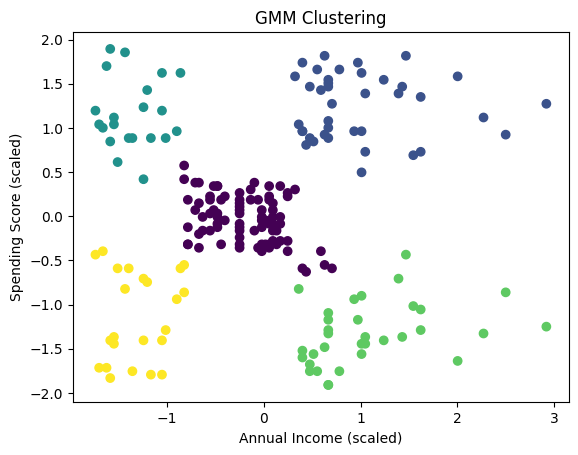

In [38]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_gmm)
plt.title('GMM Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

In [39]:
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels_gmm))

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


In [40]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

In [41]:
gmm = GaussianMixture(n_components=5, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

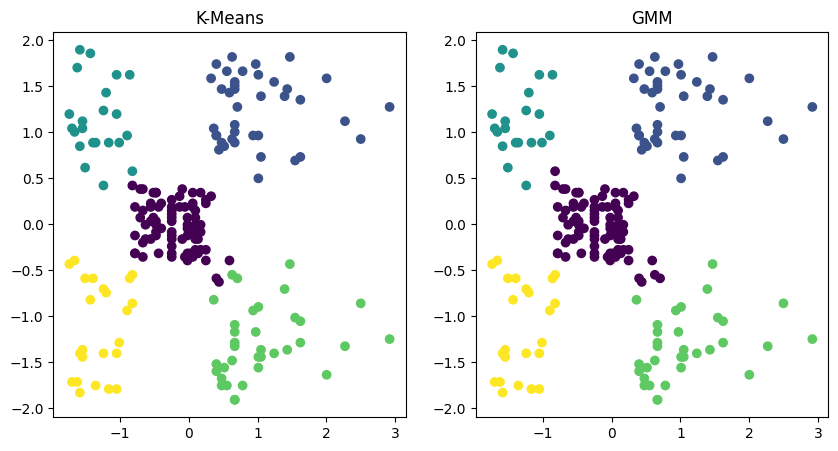

In [42]:
plt.figure(figsize=(10,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.title('K-Means')

# GMM
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_gmm)
plt.title('GMM')

plt.show()

In [43]:
df['KMeans_Cluster'] = labels_kmeans
df['GMM_Cluster'] = labels_gmm

In [44]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'GMM_Cluster', 'KMeans_Cluster'],
      dtype='object')


In [45]:
print("K-Means Cluster Summary:")
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))

print("\nGMM Cluster Summary:")
print(df.groupby('GMM_Cluster').mean(numeric_only=True))

K-Means Cluster Summary:
                CustomerID        Age  Annual Income (k$)  \
KMeans_Cluster                                              
0                86.320988  42.716049           55.296296   
1               162.000000  32.692308           86.538462   
2                23.090909  25.272727           25.727273   
3               164.371429  41.114286           88.200000   
4                23.000000  45.217391           26.304348   

                Spending Score (1-100)  GMM_Cluster  
KMeans_Cluster                                       
0                            49.518519     0.000000  
1                            82.128205     1.000000  
2                            79.363636     1.909091  
3                            17.114286     2.828571  
4                            20.913043     4.000000  

GMM Cluster Summary:
             CustomerID        Age  Annual Income (k$)  \
GMM_Cluster                                              
0             87.452381  42.714